In [6]:
import geopandas as gpd
aoi = gpd.read_file("~/Data-to-Impact-Challenge/aoi_layer/NoVA_Boundaries.geojson")
aoi = aoi.to_crs(epsg=3857) # make meters instead of lat/long

In [ ]:
import numpy as np
from shapely.geometry import box

def make_square_grid(aoi, cell_size):
    minx, miny, maxx, maxy = aoi.total_bounds
    
    xs = np.arange(minx, maxx, cell_size)
    ys = np.arange(miny, maxy, cell_size)

    squares = []
    for x in xs:
        for y in ys:
            squares.append(box(x, y, x + cell_size, y + cell_size))

    grid = gpd.GeoDataFrame(geometry=squares, crs=aoi.crs)
    return grid

grid = make_square_grid(aoi, cell_size=2500) # in meters

grid = gpd.clip(grid, aoi)

grid["grid_id"] = range(len(grid)) # make grid ids

In [24]:
grid.to_file("~/Data-to-Impact-Challenge/tessa-grid/northern_va_grid.geojson", driver="GeoJSON")
grid.to_file("~/Data-to-Impact-Challenge/tessa-grid/northern_va_grid.shp")

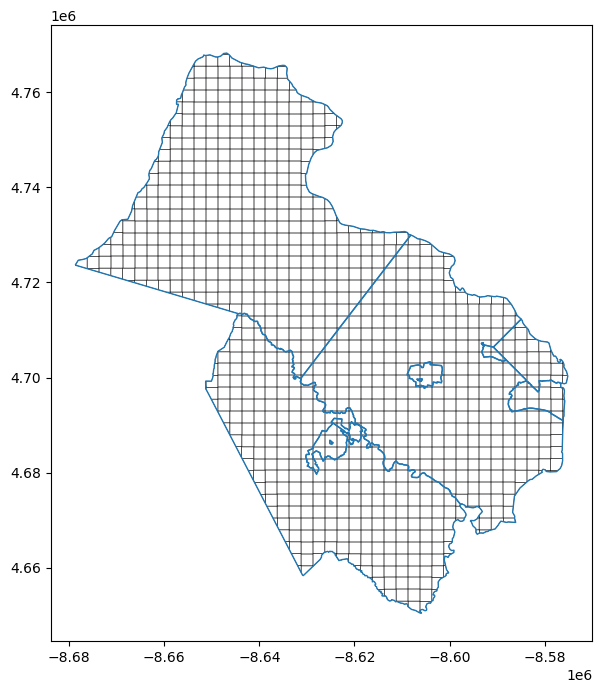

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
aoi.boundary.plot(ax=ax, linewidth=1)
grid.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.3)
plt.show()